<a href="https://colab.research.google.com/github/xsokolovae1/stanford-cs229-math-for-ML/blob/main/LinearRegressionMath.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Linear Regression

Linear regression is the problem of predicting a continuous target $y$
(house price) from a feature vector $x$ (living area, number of bedrooms),
assuming the relationship between them is approximately linear.

### Hypothesis

$$
h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2
$$

where $x_1$ is the living area, $x_2$ is the number of bedrooms, and
$\theta_i$ are the parameters we want to learn. More generally, for $n$
features:

$$
h_\theta(x) = \sum_{i=0}^{n} \theta_i x_i = \theta^T x
$$

(with the convention $x_0 = 1$, so that the intercept $\theta_0$ is also
absorbed into the sum/dot product).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
# x_train is the input variable (living area, number of bedrooms)
# y_train is the target (price of houses)
x_train = np.array([[2104, 3],
                   [1600, 3],
                   [2400, 3],
                   [1416, 2],
                   [3000,4]])

y_train = np.array([400, 330, 369, 232, 540])

m = x_train.shape[0]#number of examples
theta = np.zeros(x_train.shape[1]+1)


#let's add 1 to our X matrix, so it will be the same size as the theta and will corresponde to our formulas

ones = np.ones((5, x_train.shape[1]+1))
X = np.zeros((m, x_train.shape[1]+1))
X[:, 0] = 1
X[:, 1:] = x_train


### Cost function

Given a training set, how do we pick the parameters $\theta$? One reasonable
method is to make $h_\theta(x)$ close to $y$, at least for the training
examples we have. We define a function that measures, for each value of the
$\theta$'s, how close the $h_\theta(x^{(i)})$'s are to the corresponding
$y^{(i)}$'s — the **cost function**:

$$
J(\theta) = \frac{1}{2} \sum_{i=1}^{m} \big(h_\theta(x^{(i)}) - y^{(i)}\big)^2
$$

Note the role this function plays: $J(\theta)$ is not the thing that finds
the parameters, it's the thing that *scores* them - a single number saying
how bad a given choice of $\theta$ is across the whole training set. Finding
the $\theta$ that minimizes $J(\theta)$ is a separate step, an optimization
problem, solved here by gradient descent or the normal equations (not by
backpropagation, which is specific to multi-layer neural networks and isn't
needed for a single linear model).

> **Why the $\frac{1}{2}$?** It's purely for convenience. When we later
> differentiate $J(\theta)$, the square in $(h_\theta(x)-y)^2$ brings down a
> factor of $2$ by the chain rule:
>
> $$
> \frac{\partial}{\partial\theta_j}(h_\theta(x)-y)^2 = 2(h_\theta(x)-y)\cdot\frac{\partial h_\theta(x)}{\partial\theta_j}
> $$
>
> That $2$ cancels with the $\frac{1}{2}$ we put in front, leaving a clean
> gradient with no leftover constant:
>
> $$
> \frac{\partial}{\partial\theta_j}\,\frac{1}{2}(h_\theta(x)-y)^2 = (h_\theta(x)-y)\cdot\frac{\partial h_\theta(x)}{\partial\theta_j}
> $$
>
> Multiplying a cost function by a positive constant doesn't change *where*
> its minimum is, so the $\frac{1}{2}$ has no effect on what $\theta$ we end
> up learning —-it's there purely to make the derivative tidy.


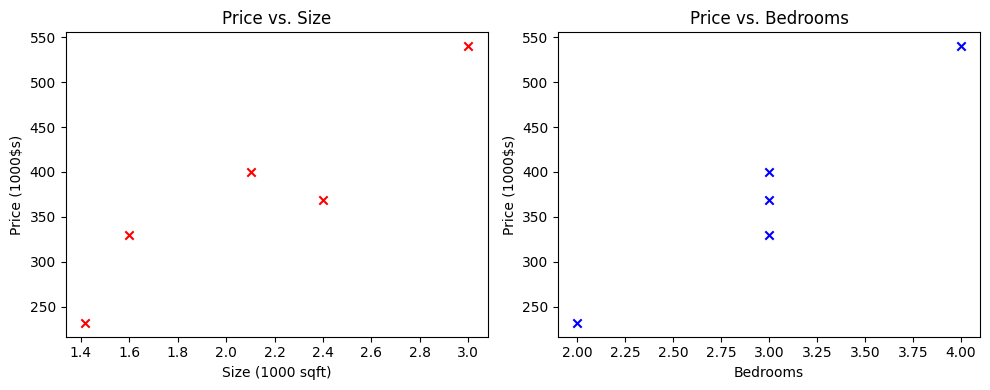

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].scatter(x_train[:, 0] / 1000, y_train, marker='x', c='r')
ax[0].set_title("Price vs. Size")
ax[0].set_xlabel('Size (1000 sqft)')
ax[0].set_ylabel('Price (1000$s)')

ax[1].scatter(x_train[:, 1], y_train, marker='x', c='b')
ax[1].set_title("Price vs. Bedrooms")
ax[1].set_xlabel('Bedrooms')
ax[1].set_ylabel('Price (1000$s)')

plt.tight_layout()
plt.show()

In [21]:
def h(X, theta): #model output

    predictions = X @ theta
    return predictions
h(X,theta)

array([0., 0., 0., 0., 0.])

In [22]:
def cost_function(X, y, theta, m):
    total = 0
    for i in range(m):
        error = X[i] @ theta - y[i]
        total += error ** 2
    return total / 2

### Deriving the gradient

Now that we have a cost function $J(\theta)$ that measures how good a given
choice of parameters is, the next question is: how do we actually find the
$\theta$ that minimizes it? Gradient descent answers this by repeatedly
taking small steps in the direction that decreases $J(\theta)$ the fastest -
the direction opposite to the gradient $\nabla_\theta J(\theta)$.

Before we can implement it, we need to derive $\frac{\partial J}{\partial
\theta_j}$ by hand.


**Step 1 — start from the cost function**, with the hypothesis written out
explicitly:

$$
J(\theta) = \frac{1}{2}\sum_{i=1}^m\Big(\sum_{k=0}^n \theta_k x_k^{(i)} - y^{(i)}\Big)^2
$$

**Step 2 — differentiate one term with respect to $\theta_j$**, using the
chain rule. For a single training example, let
$e^{(i)} = h_\theta(x^{(i)}) - y^{(i)}$:

$$
\frac{\partial}{\partial\theta_j}\frac{1}{2}\big(e^{(i)}\big)^2
= e^{(i)} \cdot \frac{\partial e^{(i)}}{\partial\theta_j}
= \big(h_\theta(x^{(i)}) - y^{(i)}\big)\cdot\frac{\partial}{\partial\theta_j}\big(h_\theta(x^{(i)}) - y^{(i)}\big)
$$

Since $y^{(i)}$ doesn't depend on $\theta$, this reduces to

$$
= \big(h_\theta(x^{(i)}) - y^{(i)}\big)\cdot\frac{\partial h_\theta(x^{(i)})}{\partial\theta_j}
$$

**Step 3 — differentiate $h_\theta(x^{(i)})$ itself.** Since
$h_\theta(x^{(i)}) = \theta_0 x_0^{(i)} + \theta_1 x_1^{(i)} + \dots + \theta_j x_j^{(i)} + \dots + \theta_n x_n^{(i)}$,
every term where the index isn't $j$ doesn't depend on $\theta_j$, so its
derivative is $0$. Only the term $\theta_j x_j^{(i)}$ survives:

$$
\frac{\partial h_\theta(x^{(i)})}{\partial\theta_j} = x_j^{(i)}
$$

**Step 4 — substitute back.** Combining steps 2 and 3, the derivative of a
single term is:

$$
\frac{\partial}{\partial\theta_j}\frac{1}{2}\big(h_\theta(x^{(i)}) - y^{(i)}\big)^2
= \big(h_\theta(x^{(i)}) - y^{(i)}\big)\, x_j^{(i)}
$$

**Step 5 — sum over all training examples.** Since $J(\theta)$ is a sum over
$i = 1, \dots, m$ and differentiation is linear, the full gradient is:

$$
\frac{\partial J(\theta)}{\partial\theta_j} = \sum_{i=1}^m \big(h_\theta(x^{(i)}) - y^{(i)}\big)\, x_j^{(i)}
$$

This is exactly the **LMS update rule** direction: each parameter $\theta_j$
moves in proportion to how much the model's errors correlate with feature
$x_j$ across the training set.

In [31]:
def numerical_gradient(cost_function, X, y, theta, m, eps=1e-4):
    n_params = theta.shape[0]
    grad = np.zeros(n_params)

    for j in range(n_params):
        theta_plus = theta.copy()
        theta_plus[j] += eps

        theta_minus = theta.copy()
        theta_minus[j] -= eps

        grad[j] = (cost_function(X, y, theta_plus, m) - cost_function(X, y, theta_minus, m)) / (2 * eps)

    return grad

In [33]:
def analytical_gradient(X, y, theta, m):
    grad = np.zeros(theta.shape[0])
    for j in range(theta.shape[0]):
        total = 0
        for i in range(m):
            total += (X[i] @ theta - y[i]) * X[i, j]
        grad[j] = total
    return grad

In [34]:
print("numerical: ", numerical_gradient(cost_function, X, y_train, theta, m))
print("analytical:", analytical_gradient(X, y_train, theta, m))

numerical:  [-1.871000e+03 -4.203712e+06 -5.921000e+03]
analytical: [-1.871000e+03 -4.203712e+06 -5.921000e+03]


In [35]:
def gradient_descent(X, y, theta, alpha, n_iters, m):
    cost_history = []

    for _ in range(n_iters):
        grad = analytical_gradient(X, y, theta, m)
        theta = theta - alpha * grad
        cost_history.append(cost_function(X, y, theta, m))

    return theta, cost_history

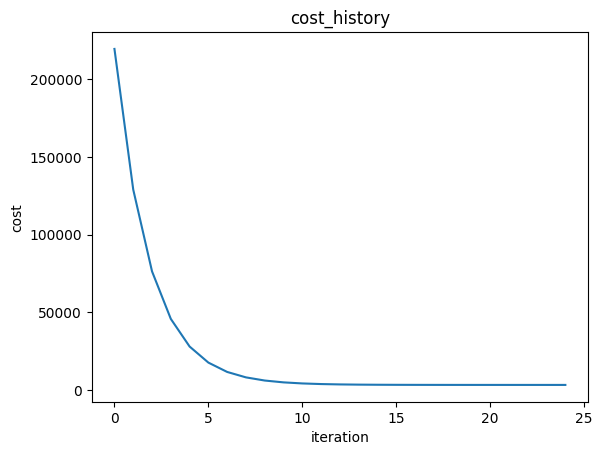

In [67]:
theta_final, cost_history = gradient_descent(X, y_train, theta, 1e-8, 25, m)
plt.plot(cost_history)
plt.xlabel('iteration')
plt.ylabel('cost')
plt.title('cost_history')
plt.show()